In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
price_file = "10 ETFs Daily close prices.csv"
ret_file   = "10 ETFs Daily returns.csv"

tickers = ["SPY", "EFA", "EEM", "TLT", "SHY", "FXE", "FXY", "DBE", "DBA", "DBB"]
equity_tickers = ["SPY", "EFA", "EEM"]  

fast_span = 15
slow_span = 120
eval_start_date = pd.Timestamp("2010-01-01")
trading_days_per_year = 252

In [3]:
def max_drawdown(nav_series):
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1.0
    mdd = drawdown.min()
    return mdd, drawdown

In [4]:
prices = pd.read_csv(price_file)
rets = pd.read_csv(ret_file)


prices["Date"] = pd.to_datetime(prices["Date"], dayfirst=True)
rets["Date"]   = pd.to_datetime(rets["Date"], dayfirst=True)


prices = prices.set_index("Date").sort_index()[tickers]
rets   = rets.set_index("Date").sort_index()[tickers]

C:\Users\91336\AppData\Local\Temp\ipykernel_32508\1871568158.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  prices["Date"] = pd.to_datetime(prices["Date"], dayfirst=True)
C:\Users\91336\AppData\Local\Temp\ipykernel_32508\1871568158.py:6: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  rets["Date"]   = pd.to_datetime(rets["Date"], dayfirst=True)


In [5]:
# EMA

ema_fast = prices.ewm(span=fast_span, adjust=False).mean()
ema_slow = prices.ewm(span=slow_span, adjust=False).mean()


ema_fast_shift = ema_fast.shift(1)
ema_slow_shift = ema_slow.shift(1)

ema_diff = ema_fast_shift - ema_slow_shift
trend_strength = ema_diff / prices  


direction = pd.DataFrame(
    np.where(ema_diff > 0, 1, -1),
    index=prices.index,
    columns=prices.columns
)


mask_nan = ema_fast.isna() | ema_slow.isna()
direction[mask_nan] = 0
trend_strength[mask_nan] = 0.0

In [6]:
direction_adj = direction.copy()
for t in equity_tickers:
    direction_adj[t] = direction_adj[t].clip(lower=0)


In [7]:
trend_strength_adj = trend_strength * (direction_adj != 0)

strength_abs = trend_strength_adj.abs()
strength_sum = strength_abs.sum(axis=1)

weight_mag = strength_abs.div(strength_sum, axis=0)
weight_mag = weight_mag.fillna(0.0)

positions_strength = weight_mag * direction_adj
positions_strength.to_excel("Trend_Following_Positions.xlsx")

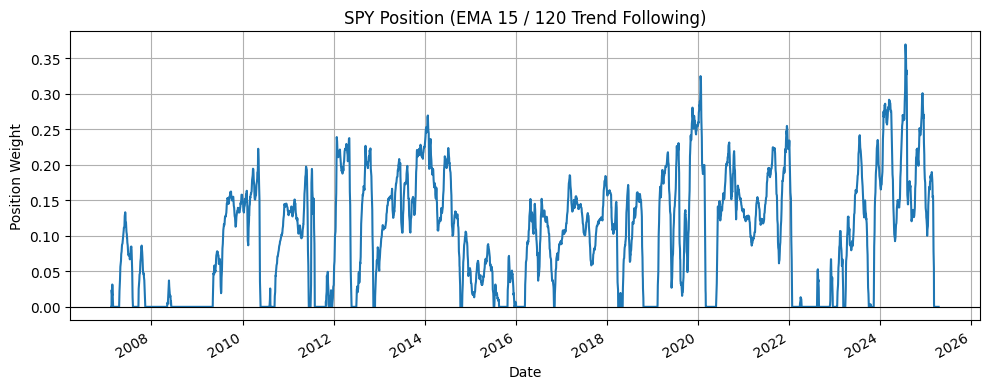

In [8]:
plt.figure(figsize=(10, 4))
positions_strength["SPY"].plot()
plt.axhline(0, color="black", linewidth=0.8)
plt.title("SPY Position (EMA 15 / 120 Trend Following)")
plt.xlabel("Date")
plt.ylabel("Position Weight")
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
active_assets = (direction_adj != 0).sum(axis=1)
positions_ew = direction_adj.div(active_assets, axis=0)
positions_ew = positions_ew.fillna(0)

rets_aligned = rets.loc[positions_ew.index]
port_ret_ew = (positions_ew * rets_aligned).sum(axis=1)

# Only evaluate performance since 2010
port_ret_ew_2010 = port_ret_ew[port_ret_ew.index >= eval_start_date]
nav_ew_2010 = (1 + port_ret_ew_2010).cumprod()

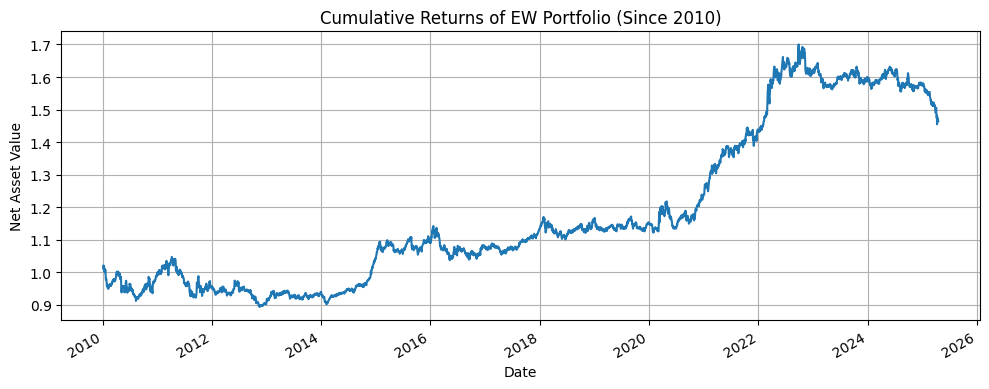

In [10]:
plt.figure(figsize=(10, 4))
nav_ew_2010.plot()
plt.title("Cumulative Returns of EW Portfolio (Since 2010)")
plt.xlabel("Date")
plt.ylabel("Net Asset Value")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
ret_series = port_ret_ew_2010.dropna()
nav_series = (1 + ret_series).cumprod()

n_days = len(ret_series)
total_return = nav_series.iloc[-1] - 1.0
annualized_return = (1.0 + total_return) ** (trading_days_per_year / n_days) - 1.0

annualized_vol = ret_series.std() * np.sqrt(trading_days_per_year)
sharpe_ratio = np.nan if annualized_vol == 0 else annualized_return / annualized_vol

mdd_value, dd_series = max_drawdown(nav_series)

print("\nPerformance Indicators (EW Portfolio, Since 2010):")
print(f"Annualized Return:      {annualized_return:.4%}")
print(f"Annualized Std Dev:     {annualized_vol:.4%}")
print(f"Sharpe Ratio (rf=0):    {sharpe_ratio:.4f}")
print(f"Maximum Drawdown (MDD): {mdd_value:.4%}")


Performance Indicators (EW Portfolio, Since 2010):
Annualized Return:      2.5277%
Annualized Std Dev:     7.0175%
Sharpe Ratio (rf=0):    0.3602
Maximum Drawdown (MDD): -14.6602%


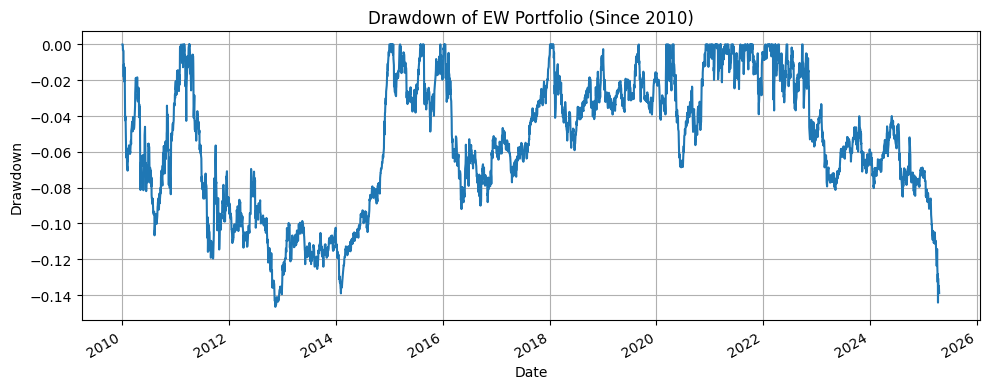

In [12]:
plt.figure(figsize=(10, 4))
dd_series.plot()
plt.title("Drawdown of EW Portfolio (Since 2010)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.tight_layout()
plt.show()